In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from glob import glob
import numpy as np
import cmocean

import cartopy.crs as ccrs
from utils import filt, interp_expert_to_unsmoothed

In [2]:
#import geopandas as gpd
def plot_sites(ax, text=True, ):
    p4=ax.plot(123.03041737634493, -14.230653066337094,'bo', markeredgecolor='k') # S245
    p5=ax.plot(122.8370658081835, -14.13718816307405,'bo', markeredgecolor='k') # W310
    p6=ax.plot(123.02928797854348, -14.052341197573492,'bo', markeredgecolor='k') # N280
    if text:
        ax.text(123.02928797854348, -14.052341197573492+0.01,'N280')
        ax.text(123.03041737634493, -14.230653066337094+0.01,'S245')
        ax.text(122.8370658081835, -14.13718816307405+0.01,'W310')
def plot_swot_basemap(ax, xlims, ylims, fine_contours=False, swath=True):

    # Add bathy etc to the plot
    #basedir = '../../MNF_SWOT/GIS'
    #swathpoly = gpd.read_file("{}/SWOT_calval_Browse_overpass_swath.shp".format(basedir))
    #swathline = gpd.read_file("{}/SWOT_calval_Browse_overpass_nadir.shp".format(basedir))
    
    # Load some bathy data
    mygroup = ''
    dsall = xr.open_dataset(f'{mygroup}/data/Bathymetry/GA_WEL_NWS_250m_DEM.nc')
    dsZ = dsall.assign_coords(nx=dsall.X,ny=dsall.Y).sel(nx=slice(xlims[0],xlims[1]), ny=slice(ylims[0], ylims[1]))
    
    cbathy= ax.contour(dsZ['X'],dsZ['Y'],-dsZ['topo'],[100,200,300,400, 500],colors='k',linewidths=0.5)
    if fine_contours:
        c_= ax.contour(dsZ['X'],dsZ['Y'],-dsZ['topo'],np.arange(100,500,10),colors='c',linewidths=0.2)

    #p1=ax.plot(123.16238333,-14.23543333,'md') # BRW mooring=
    plot_sites(ax)
    #ax.text(123.16238333,-14.23543333+0.03, 'NWSBRW')
    #if swath:
    #    p2=swathpoly.plot(ax=ax, facecolor='#859101', alpha=0.25, zorder=1e6)


    ax.set_xlim(xlims)
    ax.set_ylim(ylims)
    ax.set_aspect('equal')  

    plt.clabel(cbathy, fontsize=9)
    ax.set_ylabel(r'Latitude [$^{\circ}$N]')
    ax.set_xlabel(r'Longitude [$^{\circ}$E]')

    #del swathpoly
    #del swathline
    del dsZ
    
    return cbathy

In [3]:
plt.rcParams['font.size']=12
plt.rcParams['axes.labelsize']='small'

In [79]:
region = 'browsebasin'
#area = [122.3, -14.5, 124, -13.5] 
# area = [122.5, -14.4, 123.3, -13.5] # Zoom 
area = [122.5, -14.4, 123.2, -13.6] # Zoom 

x1,y1,x2,y2=area
satpass = '021' # 062 or 131

# xlims, ylims = [122.55,122.95], [-14.15,  -13.9] # NW of the moorings
# xlims, ylims = [122.60,122.85], [-14.14,  -13.8] # NW of the moorings (large)

# Mode-2 
cycle = '513' # May 7
xlims, ylims = [122.60,123.15], [-14.3,  -13.8] # NW of the moorings (large)

# cycle = '524' # May 18
# xlims, ylims = [122.60,123.15], [-14.3,  -13.8] # NW of the moorings (large)
# xlims, ylims = [122.65,123.05], [-14.2,  -13.8] # Zoom limits of the wave

# cycle = '514' # May 8
# xlims, ylims = [122.8,123.1], [-14.3,  -14.00] # Zoom limits of the wave

# cycle = '515' # May 9
# xlims, ylims = [122.8,123.1], [-14.3,  -14.00] # Zoom limits of the wave

# cycle = '516' # May 10
# xlims, ylims = [122.8,123.1], [-14.3,  -14.00] # Zoom limits of the wave

# cycle = '517' # May 11
# xlims, ylims = [122.8,123.1], [-14.3,  -14.00] # Zoom limits of the wave

#526, 527, 528 missing
# cycle = '530' # May 23 # corrupted
# xlims, ylims = [122.8,123.1], [-14.3,  -14.00] # Zoom limits of the wave

sigma_min, sigma_max = -5, 5
# xlims, ylims = [122.8,123.15], [-14.3,  -14.00] # Zoom limits of the wave

# Mode-1
cycle = '504' # Apr 28
xlims, ylims = [122.8,123.15], [-14.3,  -14.00] # Zoom limits of the wave

# cycle = '502' # Apr 26
# xlims, ylims = [122.8,123.15], [-14.3,  -14.00] # Zoom limits of the wave

# cycle = '503' # Apr 27
# xlims, ylims = [122.8,123.15], [-14.3,  -14.00] # Zoom limits of the wave

# sigma_min, sigma_max = -20, 20
# xlims, ylims = [122.8,123.15], [-14.3,  -14.00] # Zoom limits of the wave

version = 'L2'
# sigma_min, sigma_max = -20, 20
# L2 version C
if version=='L2':
    #ncfiles = sorted(glob(f'/data/SWOT/l2_karin_unsmoothed/cycle_{cycle}/*_{satpass}*.nc'))
    #ncfiles_2k = sorted(glob(f'/data/SWOT/l2_karin_versionC/cycle_{cycle}/*_{satpass}*.nc'))
    ncfiles = sorted(glob(f'/data/SWOT_Cruise/GRL_archive/SWOT/cycle_{cycle}/*Unsmoothed_{cycle}_{satpass}*.nc'))
    ncfiles_2k = sorted(glob(f'/data/SWOT_Cruise/GRL_archive/SWOT/cycle_{cycle}/*Expert_{cycle}_{satpass}*.nc'))


elif version=='L3':
    # L3 version 2.0.1
    ncfiles = sorted(glob(f'/data/SWOT/l3_karin_unsmoothed_v2_0_1/cycle_{cycle}/*_{satpass}*.nc'))

ncfiles#, ncfiles_2k


['/data/SWOT_Cruise/GRL_archive/SWOT/cycle_504/SWOT_L2_LR_SSH_Unsmoothed_504_021_20230428T102255_20230428T111322_PGC0_02.nc']

In [80]:
if version=='L3':

    dsall = xr.open_dataset(ncfiles[0])
    # Subsample
    ds = dsall
    selection = (
        (ds.longitude > area[0]) &
        (ds.longitude < area[2]) &
        (ds.latitude > area[1]) &
        (ds.latitude < area[3]))
    selection = selection.compute()
    ds_area = ds.where(selection, drop=True)
    timestr = ds_area['time'][100,100].values
    ssha = ds_area['ssha_unfiltered']
    var2 = 'sigma0'

In [81]:
def subsample_ds(ds, area):
    selection = (
        (ds.longitude > area[0]) &
        (ds.longitude < area[2]) &
        (ds.latitude > area[1]) &
        (ds.latitude < area[3]))
    selection = selection.compute()
    return ds.where(selection, drop=True)
    
if version=='L2':
    dsall = xr.open_dataset(ncfiles[0], group='left')
    # Subsample
    ds_area = subsample_ds(dsall, area)
    dsall = xr.open_dataset(ncfiles_2k[0])

    ds_area_2k = subsample_ds(dsall,area)

    var2 = 'sig0_karin_2'
    var1 = 'ssh_karin_2'
    
    # var1 = 'mean_sea_surface_cnescls'
    xin, yin = ds_area_2k['longitude'].values, ds_area_2k['latitude'].values
    xout, yout = ds_area['longitude'].values, ds_area['latitude'].values
    height_cor_xover = interp_expert_to_unsmoothed(xin, yin,
                            ds_area_2k['height_cor_xover'].values,
                            xout, yout)
    ocean_tide_fes = interp_expert_to_unsmoothed(xin, yin, ds_area_2k['ocean_tide_fes'].values, xout, yout)
    solid_earth_tide = interp_expert_to_unsmoothed(xin, yin, ds_area_2k['solid_earth_tide'].values, xout, yout)
    internal_tide_hret = interp_expert_to_unsmoothed(xin, yin, ds_area_2k['internal_tide_hret'].values, xout, yout)
    pole_tide = interp_expert_to_unsmoothed(xin, yin, ds_area_2k['pole_tide'].values, xout, yout)
    dac = interp_expert_to_unsmoothed(xin, yin, ds_area_2k['dac'].values, xout, yout)
    #ssha = ds_area[var1]*0  - xcor_unsmoothed
    ssha =  ds_area[var1] \
        + height_cor_xover \
        - ds_area['mean_sea_surface_cnescls']\
        - ocean_tide_fes \
        - solid_earth_tide \
        - internal_tide_hret\
        - pole_tide \
        - dac    
    #ssh_karin_2 - mean_sea_surface_cnescls - solid_earth_tide - ocean_tide_fes – internal_tide_hret - pole_tide - dac
    timestr = ds_area_2k.attrs['time_coverage_start']#.replace('-','').replace(':','')

    


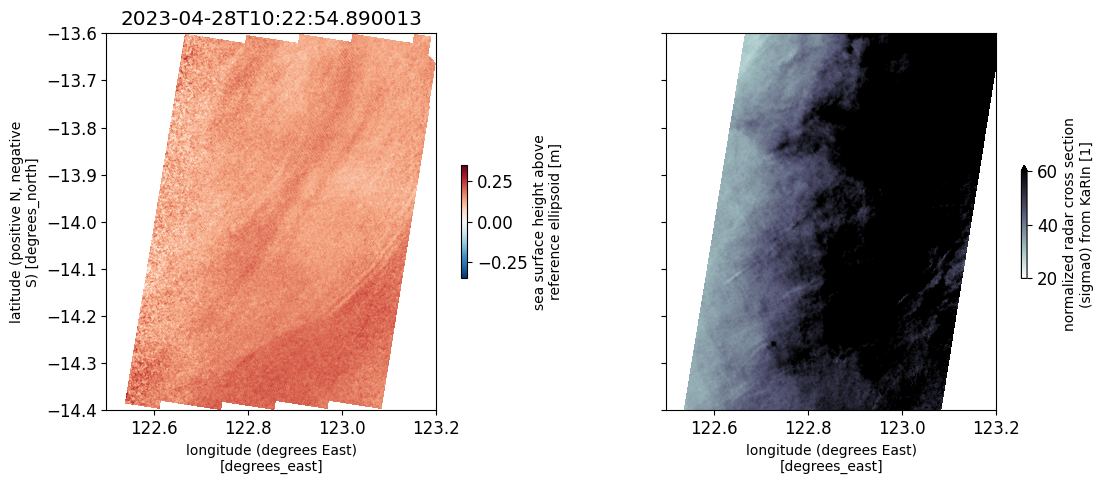

In [82]:
# var1 = 'ssha_unedited'
# var1 = 'ssha_unfiltered'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))
plot_kwargs = dict(
    x="longitude",
    y="latitude",
    cmap="RdBu_r",
    vmin=-0.35,
    vmax=0.35,
    cbar_kwargs={"shrink": 0.3},)

ssha.plot.pcolormesh(ax=ax1, **plot_kwargs)
# ax1.pcolormesh(xs,ys,np.abs(dxs+1j*dys), vmin=0, vmax=0.1, cmap='bone_r', alpha=0.2)
# u,v = ds_area.isel(satpass=swottime)['ugosa'], \
#         ds_area.isel(satpass=swottime)['vgosa']
# ax1.quiver(xs, ys, u, v, scale_units='xy', scale=10)

ax1.set_title(timestr)

# var2 = 'sigma0'
plot_kwargs = dict(
    x="longitude",
    y="latitude",
    #cmap="cmo.gray",
    cmap='bone_r',
    vmin=20,
    vmax=60,
    cbar_kwargs={"shrink": 0.3},)

ds_area[var2].plot.pcolormesh(ax=ax2, **plot_kwargs)

ax1.set_xlim(x1,x2)
ax1.set_ylim(y1,y2)
ax1.set_aspect('equal')
ax2.set_xlim(x1,x2)
ax2.set_ylim(y1,y2)
ax2.set_aspect('equal')
ax2.set_ylabel('')
ax2.set_yticklabels([])
plt.tight_layout()

# timestr = ds_area.attrs['time_coverage_start'].replace('-','').replace(':','')
# outfile = f'FIGURES/SWOT_L3_unsmoothed_{region}_{timestr}.png'
#plt.savefig(outfile)
# outfile

# Slice the SSH along a line
AI prompt:
- python code to find the coordinates of a point that is Z distange and theta angle from a first point with coordinate x,y
- convert to compass direction

In [83]:
# !pip install git+https://github.com/mrayson/sfoda.git
from scipy.interpolate import interp1d, PchipInterpolator
from sfoda.utils.myproj import MyProj
from sfoda.utils.barycentric import BarycentricInterp

def find_new_point(x, y, Z, theta_compass):
    theta_degrees = (90 - theta_compass) % 360
    theta_radians = np.radians(theta_degrees)
    x_new = x + Z * np.cos(theta_radians)
    y_new = y + Z * np.sin(theta_radians)
    return x_new, y_new

def gen_line_coords(x0 ,x1, y0, y1, dx):
    ## Generate x and y slice coordinates
    minx = np.min([x0,x1])
    maxx = np.max([x0,x1])
    lon = np.arange(minx, maxx, dx)
    Fx = interp1d([x0,x1],[y0,y1])
    lat = Fx(lon)
    return lon, lat

def compute_cumulative_distance_np(coords):
    # Compute differences between consecutive points
    deltas = np.diff(coords, axis=0)
    # Compute Euclidean distances for each segment
    distances = np.linalg.norm(deltas, axis=1)
    # Sum the distances
    return np.insert(np.cumsum(distances),0 ,0)

def interp_swot_line(zvar, lon0, lat0, dist, dirn, dx):
    P = MyProj('merc')
    x0,y0 = P(lon0,lat0)
    
    x1, y1 = find_new_point(x0, y0, dist, dirn)
    
    xl, yl = gen_line_coords(x0 ,x1, y0, y1, dx)

    idx = ~np.isnan(zvar.values)
    xg, yg = P(zvar['longitude'].values[idx], zvar['latitude'].values[idx])
    
    G = BarycentricInterp(np.array([xg,yg]).T, np.array([xl, yl]).T)

    dl = compute_cumulative_distance_np(np.array([xl, yl]).T)

    return G(zvar.values[idx]), xl, yl, dl

In [84]:
uvdir = '/data/SWOT_Cruise/GRL_archive/UV'
tdir = '/data/SWOT_Cruise/GRL_archive/TS'
etadir = '/data/SWOT_Cruise/GRL_archive/eta'

sites = {}

sites.update({'W310':
              {'uvfile':f'{uvdir}/[BB23]_[BB23_REC]_[W310]_[multi(2)_nominal_instrument_height_asb]_[multi(2)_instrument_model]_[multi(2)_instrument_serial_number]_[no_outfile_append].nc',
              'tfile': f'{tdir}/BB23_W310_stacked_TSP.nc',
              'sig1000file':f'{uvdir}/BB23_W310_VEL_BM_ENU_stacked.nc',
              'etafile': f'{etadir}/mooring_sealevel_W310_v3.nc' ,
              'z_bot':-314,
              'color':'#1f77b4',
              }
             })

sites.update({'S245':
              {'uvfile':f'{uvdir}/[BB23]_[BB23_REC]_[S245]_[5]_[Quartermaster]_[11795]_[no_outfile_append].nc',
              'tfile': f'{tdir}/BB23_S245_stacked_TSP.nc',
              'sig1000file':f'{uvdir}/BB23_S245_VEL_BM_ENU_stacked.nc',
              'etafile': f'{etadir}/mooring_sealevel_S245_v3.nc' ,
              'z_bot':-254,
              'color':'#ff7f0e',
              }
             })

sites.update({'N280':
              {'uvfile':f'{uvdir}/[BB23]_[BB23_REC]_[N280]_[5]_[Longranger]_[24613]_[no_outfile_append].nc',
              'tfile': f'{tdir}/BB23_N280_stacked_TSP.nc',
              #'etafile': f'{etadir}/mooring_steric_ssh_N280_v4.nc',
              'etafile': f'{etadir}/mooring_sealevel_N280_v8.nc',
              'z_bot':-276,
              'color':'#d62728'
              }
             })



# Filter the moorings
eta_f_all = {}
for mooring in ['S245', 'N280', 'W310']:
    eta_ds = xr.open_dataset(sites[mooring]['etafile'])
    eta_s = filt(eta_ds['eta_steric'], 4*3600, 60, btype='high')
    eta_ds['eta_steric'][:] = eta_s
    
    if 'eta_b' in list(eta_ds.keys()):
        eta_b = filt(eta_ds['eta_b'].fillna(0)-eta_ds['eta_tide_fes'].isel(lon=0),\
                     4*3600, 60, btype='high')
        eta_ds['eta_b'][:] = eta_b

    if 'eta' in list(eta_ds.keys()):
        eta = filt(eta_ds['eta'], 4*3600, 60, btype='high')
        eta_ds['eta'][:] = eta

    eta_f_all.update({mooring:eta_ds})


123.03041737634491 -14.230653066337098
123.03715474097581 -14.224080994512581
123.0438921056067 -14.217508729188188
123.05062947023761 -14.210936270445584
123.0573668348685 -14.204363618366433
123.0641041994994 -14.197790773032422
123.0708415641303 -14.19121773452526
123.0775789287612 -14.184644502926655


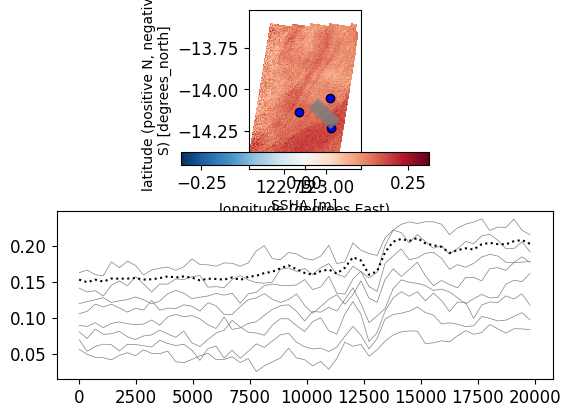

In [85]:
# zvar = (ds_area[var1]-ssha_f)
zvar = ssha

###
# Mode 1 - April 27
#Generate 10 lines 500 m apart
mooring = 'S245'
lon0, lat0 = 123.03041737634493, -14.230653066337094  # S245
dist1 = 7500
dirn1 = 45 #50 #+180
dx1 = 750

# Interpolate data from each point on a line
dist = 20000 # Mode-1
dirn = dirn1 + 270 #320
dx = 250

# Mode-1
time_guess = ds_area['time'][100,100].values
c_guess = 1.1 #1.15
z_offset = -0.12

###
# Mode 2 - May 7 (S245)
# #Generate 10 lines 500 m apart
# mooring = 'S245'
# lon0, lat0 = 123.03041737634493, -14.230653066337094  # S245
# dist1 = 7500
# dirn1 = 45 #50 #+180
# dx1 = 750

# # Interpolate data from each point on a line
# dist = 20000 # Mode-1
# dirn = dirn1 + 270 #320
# dx = 250

# # Mode-2
# time_guess = ds_area['time'][100,100].values
# c_guess = 0.60 #1.15
# z_offset = -.12

# ####
# # Mode 2 May -7
# mooring = 'W310'
# lon0, lat0 = 122.8370658081835 -0.01, -14.13718816307405 - 0.01 # W310
# dirn1 = 35 #30
# dist1 = 7500#5000
# dx1 = 500 #250

# lon0 += 0.01
# lat0 += 0.01

# dirn = dirn1 + 270 #310 #300
# dist = 25000 # Mode-2
# dx = 250

# # Mode-2
# time_guess = ds_area['time'][100,100].values
# c_guess = 0.85
# z_offset = -0.1
####

P = MyProj('merc')
x0,y0 = P(lon0,lat0)

x1, y1 = find_new_point(x0, y0, dist1, dirn1)
    
xl, yl = gen_line_coords(x0 ,x1, y0, y1, dx1)
lonl, latl = P.to_ll(xl, yl)

zs=[]
xline=[]
yline=[]
dline=[]
for lo0, la0 in zip(lonl, latl):
    print(lo0, la0)

    z_line, xl, yl, dl = interp_swot_line(zvar, lo0, la0, dist, dirn, dx)
    zs.append(z_line)
    xline.append(xl)
    yline.append(yl)
    dline.append(dl)
#ax2.plot(lonl,latl,'r.')


####
cbar_kwargs = {"shrink": 0.5, "pad":-0.10, 
               #"anchor":(0.5, 0.8), 
               "orientation":'horizontal',
               'label':r'SSHA [m]',
              "ticks":[-0.25, 0, 0.25],}

plot_kwargs = dict(
    x="longitude",
    y="latitude",
    cmap="RdBu_r",
    vmin=-0.3,
    vmax=0.3,
    cbar_kwargs=cbar_kwargs,)

ax2=plt.subplot(211)
zvar.plot.pcolormesh(ax=ax2, **plot_kwargs)
plot_sites(ax2, text=False)

for xl, yl in zip(xline, yline):
    lonl, latl = P.to_ll(xl, yl)
    ax2.plot(lonl, latl,'.',c='0.5', ms=0.5)
    
ax2.set_aspect('equal')

ax1 = plt.subplot(212)
z_off = z_offset*1 
for dl, z_line in zip(dline, zs):
    ax1.plot(dl, z_line + z_off,'0.5', lw=0.5)
    z_off +=0.02

ax1.plot(dl, np.array(zs).mean(axis=0),'k:')


In [86]:
15000/(290*60)

0.8620689655172413

In [87]:
# Get the swot time from the point closest to S245

t_swot = np.array([np.datetime64(time_guess) + np.timedelta64(int(dd/c_guess),'s') for dd in dl[::-1]])

# plt.figure()
# ax1=plt.subplot(211)
# ax1.plot(t_swot, np.array(z).mean(axis=0),'k:')
time_guess, ds_area['time'][100,100].values, t_swot

(numpy.datetime64('2023-04-28T10:44:22.631126528'),
 numpy.datetime64('2023-04-28T10:44:22.631126528'),
 array(['2023-04-28T15:44:21.631126528', '2023-04-28T15:38:59.631126528',
        '2023-04-28T15:33:38.631126528', '2023-04-28T15:28:16.631126528',
        '2023-04-28T15:22:55.631126528', '2023-04-28T15:17:34.631126528',
        '2023-04-28T15:12:12.631126528', '2023-04-28T15:06:51.631126528',
        '2023-04-28T15:01:29.631126528', '2023-04-28T14:56:08.631126528',
        '2023-04-28T14:50:46.631126528', '2023-04-28T14:45:25.631126528',
        '2023-04-28T14:40:04.631126528', '2023-04-28T14:34:42.631126528',
        '2023-04-28T14:29:21.631126528', '2023-04-28T14:23:59.631126528',
        '2023-04-28T14:18:38.631126528', '2023-04-28T14:13:17.631126528',
        '2023-04-28T14:07:55.631126528', '2023-04-28T14:02:34.631126528',
        '2023-04-28T13:57:12.631126528', '2023-04-28T13:51:51.631126528',
        '2023-04-28T13:46:30.631126528', '2023-04-28T13:41:08.631126528',
        

In [88]:


t1 = t_swot[-1]
t2 = t_swot[0]

# t1 = np.datetime64(time_guess) - np.timedelta64(6*3600,'s')
# t2 = np.datetime64(time_guess) + np.timedelta64(6*3600,'s')
 
# eta_ds = xr.open_dataset(sites[mooring]['etafile']).sel(time=slice(t1,t2))
eta_ds = eta_f_all[mooring].sel(time=slice(t1,t2))


In [90]:
15000/(5*3600), 7500 / (116*60)

(0.8333333333333334, 1.0775862068965518)

# The good figure hydrostatic figure...

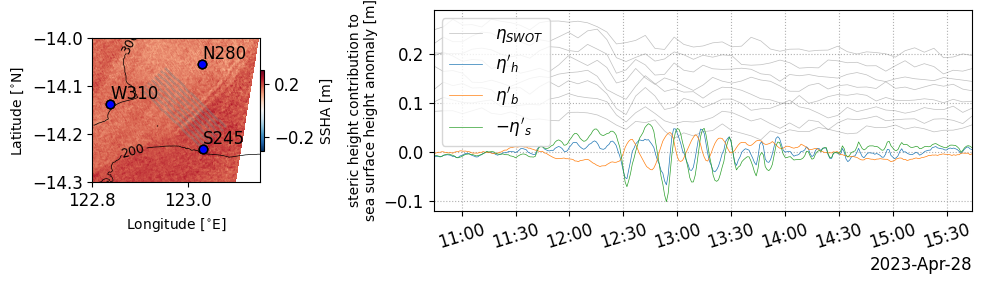

In [91]:
####
cbar_kwargs = {"shrink": 0.4, "pad":-0.0, 
               #"anchor":(0.5, 0.8), 
               "orientation":'vertical',
               'label':r'SSHA [m]',
              "ticks":[-0.2,  0.2],}

plot_kwargs = dict(
    x="longitude",
    y="latitude",
    cmap="RdBu_r",
    vmin=-0.3,
    vmax=0.3,
    cbar_kwargs=cbar_kwargs,)

plt.figure(figsize=(10,3))
ax0=plt.subplot2grid((1,3),(0,0), rowspan=1)
zvar.plot.pcolormesh(ax=ax0, **plot_kwargs)
plot_sites(ax0, text=False)

for xl, yl in zip(xline, yline):
    lonl, latl = P.to_ll(xl, yl)
    ax0.plot(lonl, latl,'.',c='0.5', ms=0.5)

# area = [122.5, -14.4, 123.2, -13.6] # Zoom 
# x0,y0,x1,y1 = area
# plot_swot_basemap(ax0, [x0,x1], [y0,y1], fine_contours=False)

plot_swot_basemap(ax0, xlims, ylims, fine_contours=False)
plot_sites(ax0, text=False)

###
ax1=plt.subplot2grid((1,3),(0,1), colspan=2)

z_off = z_offset * 1
for dl, z_line in zip(dline, zs):
    p1, = ax1.plot(t_swot, z_line + z_off,'0.5', lw=0.5, alpha=0.5)
    z_off += 0.025
    
# p1, = ax1.plot(t_swot, np.array(z).mean(axis=0) + z_offset,'k:')\

# p2, = (eta_ds['eta']-eta_ds['eta_tide_fes']).plot(ls='-',lw=0.5, ax=ax1)
p2, = (eta_ds['eta_b']-eta_ds['eta_steric']).plot(ls='-',lw=0.5, ax=ax1)
p3, = eta_ds['eta_b'].plot(ls='-',lw=0.5, ax=ax1)
p4, = (-eta_ds['eta_steric']).plot(ls='-',lw=0.5, ax=ax1)
#ax1.set_xticklabels([])
ax1.set_xlabel('')

ax1.set_xlim(t1,t2)
ax1.grid(True, ls=':')
#ax1.set_ylim(-0.15,0.25)
ax1.set_title('')
# ax1.set_ylabel('SSHA [m]')
plt.legend((p1,p2, p3, p4),(r"$\eta_{SWOT}$",r"$\eta'_h$",r"$\eta'_b$", r"$-\eta'_s$"))
plt.xticks(rotation=17)
plt.tight_layout()

# Non-hydrostatic pressure calculation

In [92]:
from scipy.signal import convolve2d

def smooth_uvw(uv_ds, varname='w', nsmooth=5):
    
    F = 1/nsmooth*np.ones((nsmooth,1)) # depth only

    w=uv_ds[varname].values
    w[np.isnan(w)] = 0.0
    wf = convolve2d(w, F, mode='same')
    
    wf_ds = uv_ds[varname].copy()
    wf_ds[:] = wf

    return wf_ds


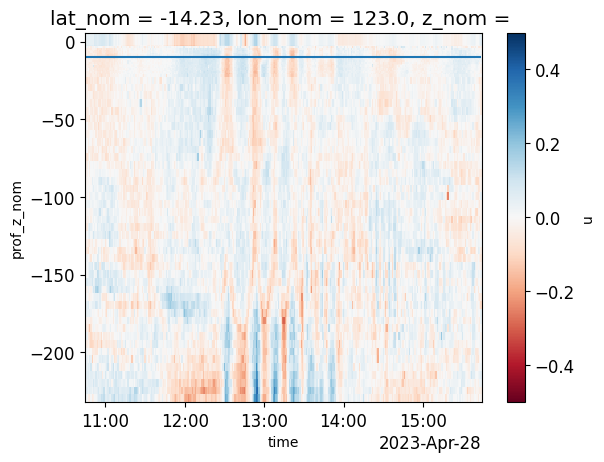

In [93]:
#ds=xr.open_dataset(sites[mooring]['sig1000file']).sel(time=slice(t1,t2))

# Filter the data first
ds_f = xr.open_dataset(sites[mooring]['sig1000file'])
eta_s = filt(ds_f['u'].fillna(0), 4*3600, 60, btype='high')
ds_f['u'][:] = eta_s
eta_s = filt(ds_f['v'].fillna(0), 4*3600, 60, btype='high')
ds_f['v'][:] = eta_s

# eta_s = filt(ds_f['v'].fillna(0), 4*3600, 60, btype='high')
# ds_f['v'][:] = eta_s

ds = ds_f.sel(time=slice(t1,t2))

## Smooth the data second
w_s = smooth_uvw(ds)
u_s = smooth_uvw(ds, varname='u')
v_s = smooth_uvw(ds, varname='v')


# Mode-1
c = 1.1
z= -10
rotation = 55

# Mode-2 S245
# c = 0.6
# z= -12
# rotation = 30 

# Mode-2 W310
# c = 0.85
# z= -12 #-12
# rotation = 35 #+ 180

###

#ds['w'].plot(vmin=-0.05, vmax=0.05, cmap='RdBu')
ds['u'].plot(vmin=-0.5, vmax=0.5, cmap='RdBu')

# plt.ylim(-30,2)
plt.hlines(z, ds['time'][0], ds['time'][-1])



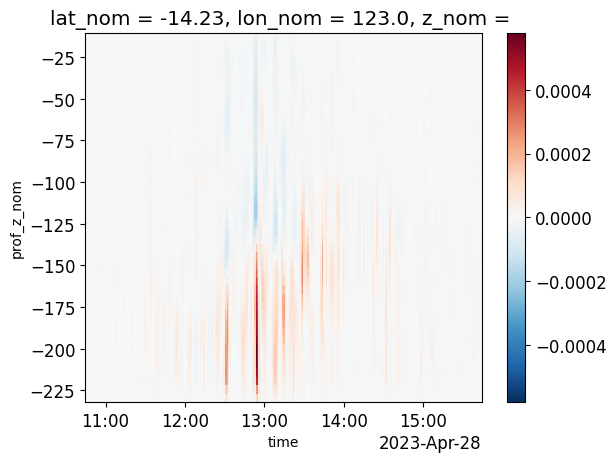

In [94]:
w = w_s.sel(prof_z_nom=slice(None, -10,None) )
#dw_dt = w.diff('time')/60
dw_dt = w.differentiate('time', datetime_unit ='s')
dw_dz = w.differentiate('prof_z_nom')

#
Z = u_s.sel(prof_z_nom=slice(None, -10,None) ) + 1j * v_s.sel(prof_z_nom=slice(None, -10,None) )
spd, dirn = np.abs(Z), np.angle(Z)
dirn += rotation*np.pi/180
u_r = spd*np.cos(dirn)

u_dw_dx = -u_r/c * dw_dt

(u_dw_dx).plot()

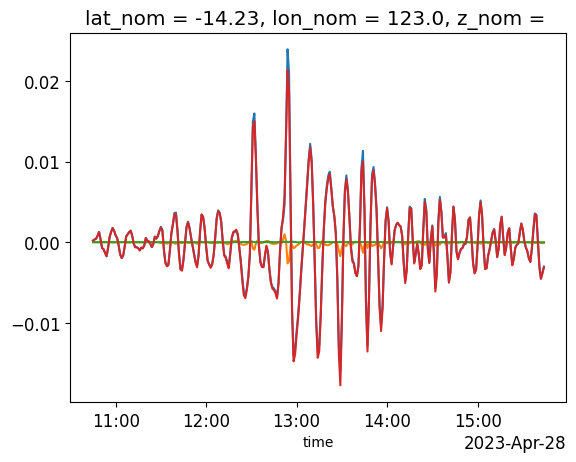

In [95]:
g = 9.81
eta_nh_1 = -dw_dt.integrate('prof_z_nom') / g
eta_nh_2 = -u_dw_dx.integrate('prof_z_nom') / g
eta_nh_3 = -(w*dw_dz).integrate('prof_z_nom') / g
eta_nh = eta_nh_1 + eta_nh_2 + eta_nh_3
eta_nh_1.plot()
eta_nh_2.plot()
eta_nh_3.plot()
eta_nh.plot()

'../FIGURES/SWOT_mooring_ssha_comparison_2023-04-28T104422_2023-04-28T154421_highpass_v2.png'

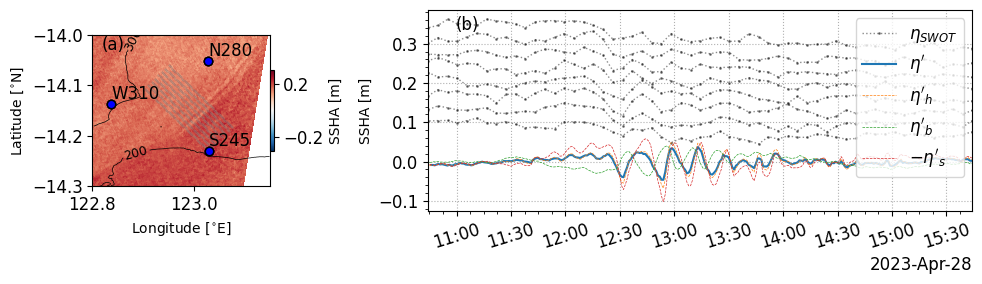

In [96]:
####
cbar_kwargs = {"shrink": 0.4, "pad":-0.0, 
               #"anchor":(0.5, 0.8), 
               "orientation":'vertical',
               'label':r'SSHA [m]',
              "ticks":[-0.2,  0.2],}

plot_kwargs = dict(
    x="longitude",
    y="latitude",
    cmap="RdBu_r",
    vmin=-0.3,
    vmax=0.3,
    cbar_kwargs=cbar_kwargs,)

plt.figure(figsize=(10,3))
ax0=plt.subplot2grid((1,3),(0,0), rowspan=1)
zvar.plot.pcolormesh(ax=ax0, **plot_kwargs)
plot_sites(ax0, text=False)

for xl, yl in zip(xline, yline):
    lonl, latl = P.to_ll(xl, yl)
    ax0.plot(lonl, latl,'.',c='0.5', ms=0.5)

# area = [122.5, -14.4, 123.2, -13.6] # Zoom 
# x0,y0,x1,y1 = area
# plot_swot_basemap(ax0, [x0,x1], [y0,y1], fine_contours=False)

plot_swot_basemap(ax0, xlims, ylims, fine_contours=False)
plot_sites(ax0, text=False)

###
ax1=plt.subplot2grid((1,3),(0,1), colspan=2)

# z_off = z_offset * 1
z_off = -0.10

for dl, z_line in zip(dline, zs):
    p1, = ax1.plot(t_swot, z_line + z_off, ls=':', marker='.', ms=2, c='0.1', lw=1, alpha=0.5)
    #z_off += 0.025
    z_off += 0.035

# p1, = ax1.plot(t_swot, np.array(z).mean(axis=0) + z_offset,'k:')\

# p2, = (eta_ds['eta']-eta_ds['eta_tide_fes']).plot(ls='-',lw=0.5, ax=ax1)
eta_h = eta_ds['eta_b']-eta_ds['eta_steric']
eta = eta_h + eta_nh.interp(time=eta_h['time'])

p2, = eta.plot(ls='-',lw=1.5, ax=ax1)
p3, = eta_h.plot(ls='--',lw=0.5, ax=ax1)

p4, = eta_ds['eta_b'].plot(ls='--',lw=0.5, ax=ax1)
p5, = (-eta_ds['eta_steric']).plot(ls='--',lw=0.5, ax=ax1)

#p4, = eta_m.plot(ls='-',lw=1, ax=ax1)

#ax1.set_xticklabels([])
ax1.set_xlabel('')

ax1.set_xlim(t1,t2)
#ax1.set_ylim(-0.15,0.25)
ax1.set_title('')
ax1.set_ylabel('SSHA [m]')
# plt.legend((p1,p2,p3),(r"$\eta_{SWOT}$",r"$\eta'$",r"$\eta'_{h}$",), loc='upper right')
plt.legend((p1,p2,p3,p4,p5),(r"$\eta_{SWOT}$",r"$\eta'$",r"$\eta'_{h}$",r"$\eta'_{b}$",r"$-\eta'_{s}$"), loc='upper right')

plt.xticks(rotation=17)
ax1.minorticks_on()
ax1.grid(True, ls=':')
plt.tight_layout()

ax0.text(0.05, 0.9, '(a)', transform=ax0.transAxes)
ax1.text(0.05, 0.9, r'(b)', transform=ax1.transAxes)

t1str = t1.astype('str')[0:19].replace(':','')
t2str = t2.astype('str')[0:19].replace(':','')
outfile = f'../FIGURES/SWOT_mooring_ssha_comparison_{t1str}_{t2str}_highpass_v2.png'

plt.savefig(outfile,dpi=150)
outfile

# Momentum-inferred sea level

In [64]:
ds=xr.open_dataset(sites[mooring]['sig1000rawfile']).sel(time=slice(t1,t2))
ds

KeyError: 'sig1000rawfile'

KeyError: "No variable named 'pressure'. Variables on the dataset include ['u', 'v', 'w', 'source', 'prof_z_nom', 'time', 'lat_nom', 'lon_nom', 'z_nom']"

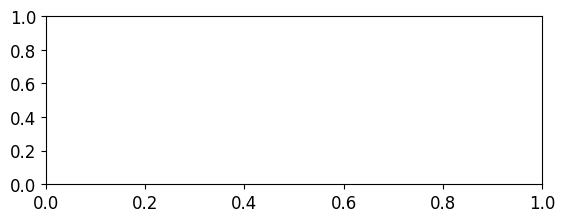

In [65]:
ax0=plt.subplot(211)
ds['pressure'].plot()
ax=plt.subplot(212, sharex=ax0)
ds['vel'].sel(dir='E').plot(vmin=-0.5, vmax=.5, cmap='RdBu', add_colorbar=False)

In [ ]:
#ds['accel'].sel(dirIMU='U').plot()
ds['accel'].sel(dirIMU='U').mean()

KeyError: "No variable named 'accel'. Variables on the dataset include ['u', 'v', 'w', 'source', 'prof_z_nom', 'time', 'lat_nom', 'lon_nom', 'z_nom']"

KeyError: "No variable named 'vel'. Variables on the dataset include ['u', 'v', 'w', 'source', 'prof_z_nom', 'time', 'lat_nom', 'lon_nom', 'z_nom']"

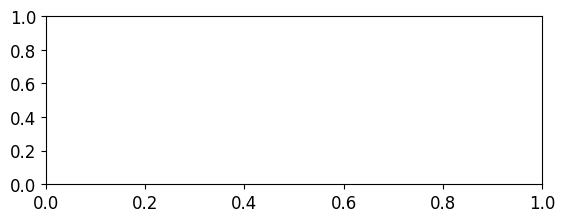

In [66]:
ax=plt.subplot(211)
ds['vel'].sel(dir='E').sel(range=230, method='nearest').plot()
ds['vel'].sel(dir='N').sel(range=230, method='nearest').plot()
ax=plt.subplot(212)
ds['accel'].sel(dirIMU='E').plot()
ds['accel'].sel(dirIMU='N').plot()

In [67]:
cutoff = 300
accel_x = filt(ds['accel'].sel(dirIMU='E'), [1800,cutoff/2], 3.0, btype='band')
ds['accel_x'] = xr.DataArray(accel_x, coords={'time':ds.time})
accel_y = filt(ds['accel'].sel(dirIMU='N'), [1800,cutoff/2], 3.0, btype='band')
ds['accel_y'] = xr.DataArray(accel_y, coords={'time':ds.time})

u = ds['vel'].sel(dir='E').sel(range=230, method='nearest')
u_f = filt(u, cutoff, 3.0, btype='low')
ds['u'] = xr.DataArray(u_f, coords={'time':ds.time})

v = ds['vel'].sel(dir='N').sel(range=230, method='nearest')
v_f = filt(v, cutoff, 3.0, btype='low')
ds['v'] = xr.DataArray(v_f, coords={'time':ds.time})

ax=plt.subplot(211)
ds['accel_x'].plot()
ds['accel_y'].plot()

ax=plt.subplot(212)
ds['u'].plot()
ds['v'].plot()

KeyError: "No variable named 'accel'. Variables on the dataset include ['u', 'v', 'w', 'source', 'prof_z_nom', 'time', 'lat_nom', 'lon_nom', 'z_nom']"

In [68]:
np.cumsum(ds['accel_x']* 3.).plot()
np.cumsum(ds['accel_y']* 3.).plot()
# plt.ylim(-1,1)

KeyError: "No variable named 'accel_x'. Variables on the dataset include ['u', 'v', 'w', 'source', 'prof_z_nom', 'time', 'lat_nom', 'lon_nom', 'z_nom']"

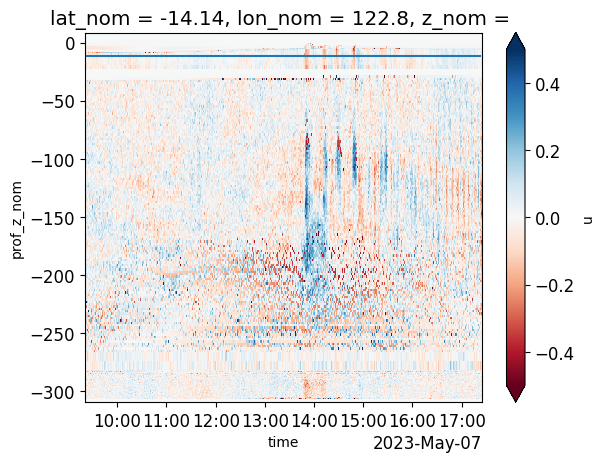

In [69]:
#ds=xr.open_dataset(sites[mooring]['sig1000file']).sel(time=slice(t1,t2))

# Filter the data first
ds_f = xr.open_dataset(sites[mooring]['sig1000file'])
eta_s = filt(ds_f['u'].fillna(0), 4*3600, 60, btype='high')
ds_f['u'][:] = eta_s
eta_s = filt(ds_f['v'].fillna(0), 4*3600, 60, btype='high')
ds_f['v'][:] = eta_s

# eta_s = filt(ds_f['v'].fillna(0), 4*3600, 60, btype='high')
# ds_f['v'][:] = eta_s

ds = ds_f.sel(time=slice(t1,t2))

## Smooth the data second
w_s = smooth_uvw(ds)
u_s = smooth_uvw(ds, varname='u')
v_s = smooth_uvw(ds, varname='v')


# Mode-1
# c = 1.1
# # c = 0.7 # testing
# z= -10
# rotation = 55

# Mode-2 S245
# c = 0.6
# z= -12
# rotation = 30 

# Mode-2 W310
c = 0.85
z= -12 #-12
rotation = 35 #+ 180

###

#ds['w'].plot(vmin=-0.05, vmax=0.05, cmap='RdBu')
ds['u'].plot(vmin=-0.5, vmax=0.5, cmap='RdBu')

# plt.ylim(-30,2)
plt.hlines(z, ds['time'][0], ds['time'][-1])

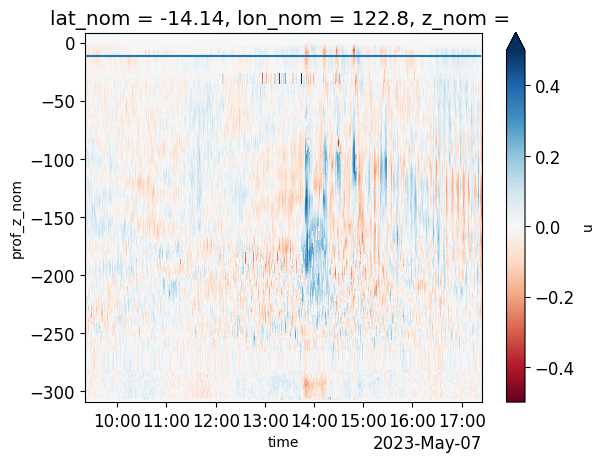

In [70]:

#w_s.plot(vmin=-0.05, vmax=0.05, cmap='RdBu')
u_s.plot(vmin=-0.5, vmax=0.5, cmap='RdBu')

# plt.ylim(-30,2)
plt.hlines(z, ds['time'][0], ds['time'][-1])

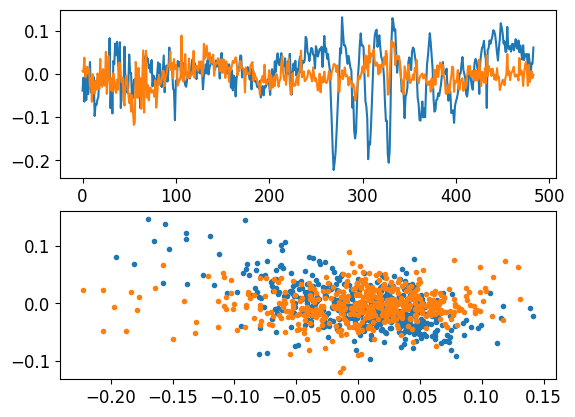

In [71]:
#myds = ds.sel(prof_z_nom=z, method='nearest')
#Z = myds['u'] +1j*myds['v']
Z = u_s.sel(prof_z_nom=z, method='nearest') + 1j * v_s.sel(prof_z_nom=z, method='nearest')

spd, dirn = np.abs(Z), np.angle(Z)
dirn += rotation*np.pi/180

u_r = spd*np.cos(dirn)
v_r = spd*np.sin(dirn)

plt.subplot(211)
plt.plot(u_r)
plt.plot(v_r)

plt.subplot(212)
plt.plot(u_s.sel(prof_z_nom=z, method='nearest'), v_s.sel(prof_z_nom=z, method='nearest'),'.')
plt.plot(u_r, v_r,'.')

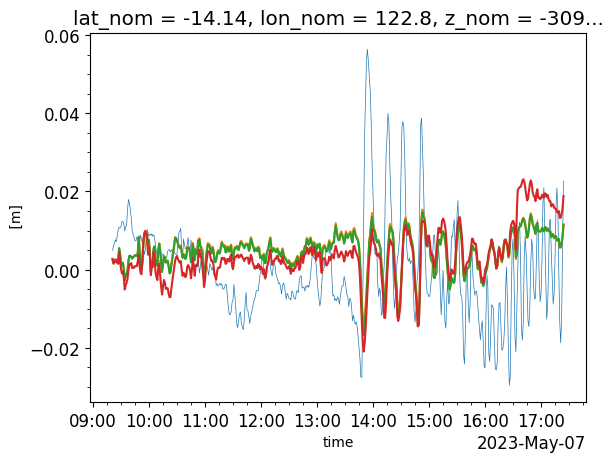

In [72]:
dz = 2.
#myds2 = ds.sel(prof_z_nom=z-dz, method='nearest')
# Z = myds2['u'] +1j*myds2['v']
Z = u_s.sel(prof_z_nom=z-dz, method='nearest') + 1j * v_s.sel(prof_z_nom=z-dz, method='nearest')
spd, dirn = np.abs(Z), np.angle(Z)
dirn += rotation*np.pi/180

u_r2 = spd*np.cos(dirn)
v_r2 = spd*np.sin(dirn)

dudz = (u_r-u_r2)/dz

#plt.plot(dudz)
#w = 0.5*(myds2['w']+myds['w'])
w = w_s.sel(prof_z_nom=z, method='nearest')
w_dudz = w*dudz

tsec = ds.time.values.astype(float)*1e-9
tsec -= tsec[0]

dt = tsec[1] - tsec[0]
dudt = np.gradient(u_r, dt)

x = -c*tsec

dudx = -1/c * dudt
u_dudx = u_r*dudx

# dx = c*dt # Check the sign!!
# eta_1 = -1/9.81 * np.cumsum(dudt[::-1]* dx)[::-1]
# eta_2 = -1/9.81 * np.cumsum((dudt+u_dudx)[::-1]* dx)[::-1]
# eta_m = -1/9.81 * np.cumsum((dudt+u_dudx+w_dudz)[::-1]* dx)[::-1]

# eta_1 = -1/9.81 * np.cumsum(dudt* dx)
# eta_2 = -1/9.81 * np.cumsum((dudt+u_dudx)* dx)
# eta_m = -1/9.81 * np.cumsum((dudt+u_dudx+w_dudz)* dx)

#dx = c*dt # Check the sign!!
# eta_1 = -c/9.81 * np.cumsum(dudt[::-1]* dt)[::-1]
# eta_2 = -c/9.81 * np.cumsum((dudt-u_r/c*dudt)[::-1]* dt)[::-1]
# eta_m = -c/9.81 * np.cumsum((dudt-u_r2/c*dudt+w_dudz)[::-1]* dt)[::-1]

eta_1 = c/9.81 * np.cumsum(dudt* dt)
eta_2 = c/9.81 * np.cumsum((dudt-u_r2/c*dudt)* dt)
eta_m = c/9.81 * np.cumsum((dudt-u_r2/c*dudt+w_dudz)* dt)

# eta_m = c/9.81 * np.cumsum((-dudt+u_r/c*dudt-w_dudz)* dt)

# 
# w.plot()
plt.figure()
ax1=plt.subplot(111)
p2, = (eta_ds['eta_b']-eta_ds['eta_steric']).plot(ls='-',lw=0.5, ax=ax1)
plt.plot(ds.time, eta_1)
plt.plot(ds.time, eta_2)
plt.plot(ds.time, eta_m)
plt.minorticks_on()
# plt.plot(x, eta_2)
# plt.plot(x, eta_3)

# Non-hydrostatic pressure calculation

'../FIGURES/acceleration_terms_2023-05-07T092002_2023-05-07T172445_highpass.png'

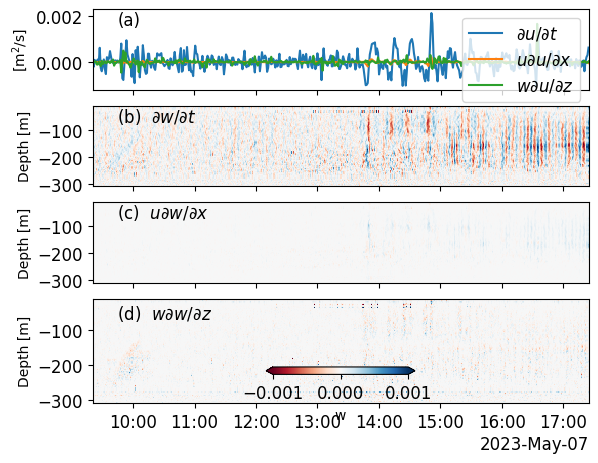

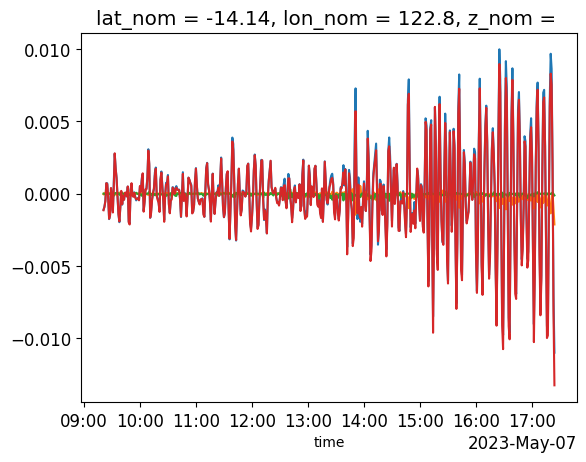

'../FIGURES/SWOT_mooring_ssha_comparison_2023-05-07T092002_2023-05-07T172445_highpass_v2.png'

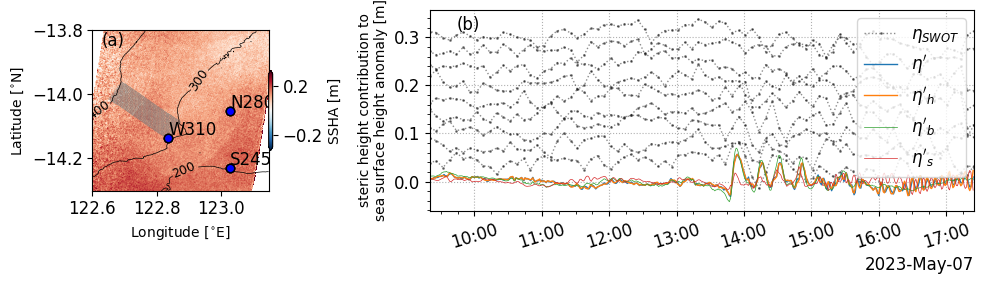

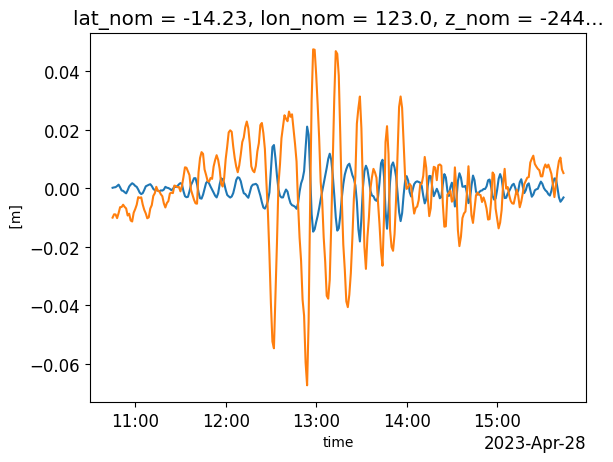

In [32]:
eta_nh.plot()
eta_h.plot()

---
# Testing below here...

(-0.15, 0.15)

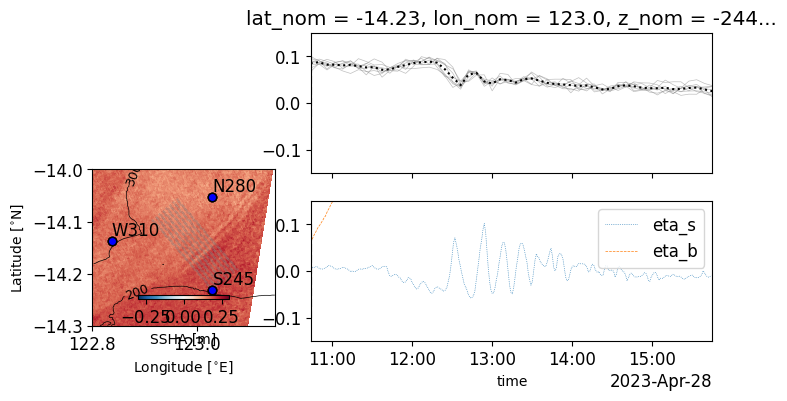

In [233]:
####
cbar_kwargs = {"shrink": 0.5, "pad":-0.10, 
               #"anchor":(0.5, 0.8), 
               "orientation":'horizontal',
               'label':r'SSHA [m]',
              "ticks":[-0.25, 0, 0.25],}

plot_kwargs = dict(
    x="longitude",
    y="latitude",
    cmap="RdBu_r",
    vmin=-0.3,
    vmax=0.3,
    cbar_kwargs=cbar_kwargs,)

plt.figure(figsize=(8,4))
ax0=plt.subplot2grid((2,3),(0,0), rowspan=2)
zvar.plot.pcolormesh(ax=ax0, **plot_kwargs)
plot_sites(ax0, text=False)

for xl, yl in zip(xline, yline):
    lonl, latl = P.to_ll(xl, yl)
    ax0.plot(lonl, latl,'.',c='0.5', ms=0.5)

plot_swot_basemap(ax0, xlims, ylims, fine_contours=False)
plot_sites(ax0, text=False)

###
ax1=plt.subplot2grid((2,3),(0,1), colspan=2)

for dl, z_line in zip(dline, zs):
    ax1.plot(t_swot, z_line + z_offset,'0.5', lw=0.5, alpha=0.5)
    
ax1.plot(t_swot, np.array(zs).mean(axis=0) + z_offset,'k:')
(eta_ds['eta']-eta_ds['eta_tide_fes']).plot(ls='-',lw=0.5, ax=ax1)
ax1.set_xticklabels([])
ax1.set_xlabel('')

ax2=plt.subplot2grid((2,3),(1,1), colspan=2)
eta_ds['eta_steric'].plot(ls=':',lw=0.5,ax=ax2)
(eta_ds['eta_b']-eta_ds['eta_tide_fes']).plot(ls='--',lw=0.5, ax=ax2)
plt.legend(('eta_s','eta_b'))
ax2.set_title('')
ax1.vlines(time_guess, ymin=-.1, ymax=0.1, color='k', ls='--', lw=1.5)
ax2.vlines(time_guess, ymin=-.1, ymax=0.1, color='k', ls='--', lw=1.5)

ax1.set_xlim(t1,t2)
ax2.set_xlim(t1,t2)

ax1.set_ylim(-0.15,0.15)
ax2.set_ylim(-0.15, 0.15)

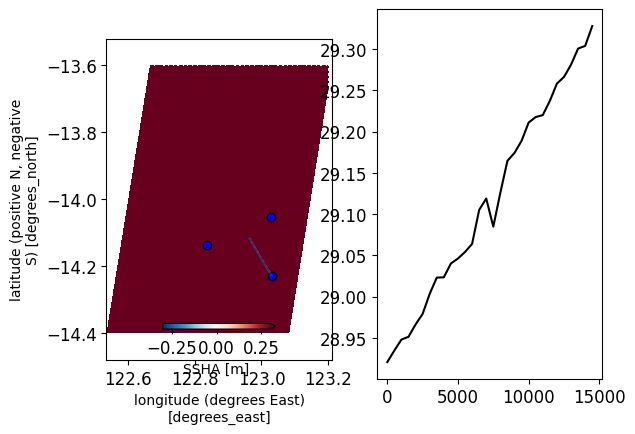

In [234]:
# p5=ax.plot(122.8370658081835, -14.13718816307405,'bo', markeredgecolor='k') # W310
# p6=ax.plot(123.02928797854348, -14.052341197573492
lon0, lat0 = 123.03041737634493, -14.230653066337094 # S245
# lon0, lat0 = 122.8370658081835, -14.13718816307405 # W310
dist = 15000
dirn = 330
dx = 250


zvar = ds_area[var1]

z_line, xl, yl, dl = interp_swot_line(zvar, lon0, lat0, dist, dirn, dx)

ax2=plt.subplot(121)
zvar.plot.pcolormesh(ax=ax2, **plot_kwargs)
plot_sites(ax2, text=False)

lonl, latl = P.to_ll(xl, yl)
ax2.plot(lonl, latl,'.', ms=0.5)
ax2.set_aspect('equal')

ax1 = plt.subplot(122)
ax1.plot(dl, z_line,'k')



NameError: name 'ssha_f' is not defined

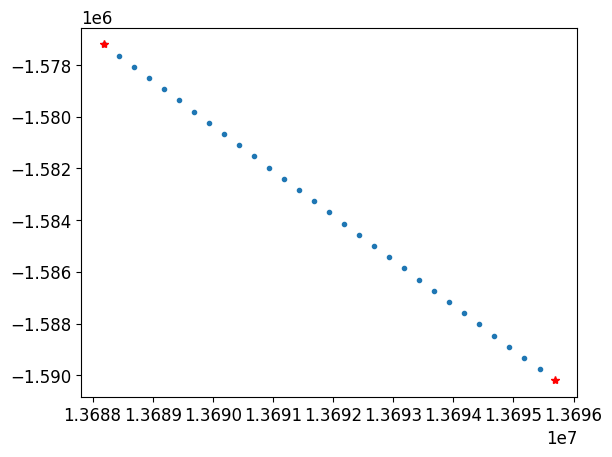

In [235]:
P = MyProj('merc')
x0,y0 = P(lon0,lat0)

x1, y1 = find_new_point(x0, y0, dist, dirn)

xl, yl = gen_line_coords(x0 ,x1, y0, y1, dx)

plt.plot(xl, yl,'.')
plt.plot([x0,x1],[y0,y1],'r*')

zvar = (ds_area[var1]-ssha_f)
zvar

# Interpolate the swot variable along the line

idx = ~np.isnan(zvar.values)
xg, yg = P(zvar['longitude'].values[idx], zvar['latitude'].values[idx])

G = BarycentricInterp(np.array([xg,yg]).T, np.array([xl, yl]).T)



In [ ]:
ax2=plt.subplot(121)
zvar.plot.pcolormesh(ax=ax2, **plot_kwargs)

lonl, latl = P.to_ll(xl, yl)
ax2.plot(lonl, latl,'.', ms=0.5)
ax2.set_aspect('equal')

ax1 = plt.subplot(122)
ax1.plot(xl, G(zvar.values[idx]))

In [ ]:



compute_cumulative_distance_np(np.array([xl, yl]).T)
